Import


In [14]:
# ==========================================
# STEP 0 — Imports
# ==========================================
import sys
print(sys.executable)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import welch, correlate
from scipy.stats import pearsonr
from scipy.ndimage import gaussian_filter
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Set plotting defaults
plt.style.use("ggplot")


c:\Users\Nicholas Santoso\AppData\Local\Programs\Python\Python314\python.exe


Load + Timestamp Alignment

In [15]:
# Replace with your file paths
wearable_path = "C:\\Users\\Nicholas Santoso\\Downloads\\recordings (week of 29th) (1)\\position - ellie 29-01-26\\LATERAL\\recording_20260129_113120.csv"
control_path = "C:\\Users\\Nicholas Santoso\\Downloads\\recordings (week of 29th) (1)\\position - ellie 29-01-26\\LATERAL\\recording_20260129_113120.csv"

wearable = pd.read_csv(wearable_path)
control = pd.read_csv(control_path)

print("Wearable shape:", wearable.shape)
print("Control shape:", control.shape)

# Ensure Timestamp column exists
assert "Timestamp" in wearable.columns
assert "Timestamp" in control.columns

# Convert Timestamps to seconds (assuming ms or string Timestamps)
wearable["Timestamp"] = pd.to_numeric(wearable["Timestamp"])
control["Timestamp"] = pd.to_numeric(control["Timestamp"])

# Resample onto a common Timestamp axis
# -------------------------------------------------
# Create a shared Timestamp vector
t_min = max(wearable.Timestamp.min(), control.Timestamp.min())
t_max = min(wearable.Timestamp.max(), control.Timestamp.max())

common_t = np.arange(t_min, t_max, step=1)   # 1 ms = 1000 Hz assumed

# Interpolate both to this common index
wearable_interp = pd.DataFrame({"Timestamp": common_t})
control_interp  = pd.DataFrame({"Timestamp": common_t})

for ch in range(1, 65):
    col = f"Channel_{ch}"
    wearable_interp[col] = np.interp(common_t,
                                     wearable.Timestamp,
                                     wearable[col])
    control_interp[col] = np.interp(common_t,
                                    control.Timestamp,
                                    control[col])

print("Resampled shape:", wearable_interp.shape)


Wearable shape: (111250, 73)
Control shape: (111250, 73)
Resampled shape: (56, 65)


Per-Channel Amplitude Metrics

In [16]:
def compute_metrics(signal):
    rms = np.sqrt(np.mean(signal**2))
    mav = np.mean(np.abs(signal))
    var = np.var(signal)
    p2p = signal.max() - signal.min()
    return rms, mav, var, p2p

results = []

for ch in range(1, 65):
    w = wearable_interp[f"Channel_{ch}"].values
    c = control_interp[f"Channel_{ch}"].values

    w_metrics = compute_metrics(w)
    c_metrics = compute_metrics(c)

    results.append([ch] + list(w_metrics) + list(c_metrics))

columns = ["channel",
           "wearable_RMS", "wearable_MAV", "wearable_VAR", "wearable_P2P",
           "control_RMS",  "control_MAV",  "control_VAR",  "control_P2P"]

amp_df = pd.DataFrame(results, columns=columns)
amp_df.head()


,channel,wearable_RMS,wearable_MAV,wearable_VAR,wearable_P2P,control_RMS,control_MAV,control_VAR,control_P2P
0,1,556.535730,215.606326,306652.380560,4481.915450,556.535730,215.606326,306652.380560,4481.915450
1,2,594.034757,228.649229,348013.960359,4664.659500,594.034757,228.649229,348013.960359,4664.659500
2,3,606.029367,234.744195,361641.598804,4724.309528,606.029367,234.744195,361641.598804,4724.309528
3,4,627.603480,259.058997,387489.480060,4845.590306,627.603480,259.058997,387489.480060,4845.590306
4,5,634.047109,259.981872,395980.038831,4834.959310,634.047109,259.981872,395980.038831,4834.959310


Time-Series Similarity (Correlation + Delay)

In [17]:
corrs = []
lags = []

for ch in range(1, 65):
    w = wearable_interp[f"Channel_{ch}"].values
    c = control_interp[f"Channel_{ch}"].values

    # Pearson correlation
    r, _ = pearsonr(w, c)
    corrs.append(r)

    # Cross-correlation to estimate delay
    cc = correlate(w - w.mean(), c - c.mean(), mode="full")
    lag = np.argmax(cc) - (len(w) - 1)
    lags.append(lag)

corr_df = pd.DataFrame({
    "channel": np.arange(1, 65),
    "correlation": corrs,
    "lag_samples": lags
})

corr_df.head()


C:\Users\Nicholas Santoso\AppData\Local\Temp\ipykernel_44104\3044579400.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(w, c)


,channel,correlation,lag_samples
0,1,1.0,0
1,2,1.0,0
2,3,1.0,0
3,4,1.0,0
4,5,1.0,0


Frequency-Domain Analysis (PSD + Median Frequency)

In [18]:
fs = 1000  # assumed sampling rate (Hz)

def median_frequency(f, Pxx):
    cumulative = np.cumsum(Pxx)
    return f[np.searchsorted(cumulative, cumulative[-1] / 2)]

freq_results = []

for ch in range(1, 65):
    w = wearable_interp[f"Channel_{ch}"].values
    c = control_interp[f"Channel_{ch}"].values
    
    # Welch PSD
    f_w, P_w = welch(w, fs=fs, nperseg=1024)
    f_c, P_c = welch(c, fs=fs, nperseg=1024)

    mf_w = median_frequency(f_w, P_w)
    mf_c = median_frequency(f_c, P_c)

    total_power_w = np.sum(P_w)
    total_power_c = np.sum(P_c)

    freq_results.append([ch, mf_w, mf_c, total_power_w, total_power_c])

freq_df = pd.DataFrame(freq_results,
    columns=["channel", "wearable_MF", "control_MF",
             "wearable_power", "control_power"])

freq_df.head()


C:\Users\Nicholas Santoso\AppData\Local\Temp\ipykernel_44104\2561818933.py:14: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 56, using nperseg = 56
  f_w, P_w = welch(w, fs=fs, nperseg=1024)
C:\Users\Nicholas Santoso\AppData\Local\Temp\ipykernel_44104\2561818933.py:15: UserWarning: nperseg=1024 is greater than signal length max(len(x), len(y)) = 56, using nperseg = 56
  f_c, P_c = welch(c, fs=fs, nperseg=1024)


,channel,wearable_MF,control_MF,wearable_power,control_power
0,1,267.857143,267.857143,27192.102618,27192.102618
1,2,267.857143,267.857143,30412.226051,30412.226051
2,3,267.857143,267.857143,31591.113445,31591.113445
3,4,267.857143,267.857143,33456.011250,33456.011250
4,5,267.857143,267.857143,34136.214161,34136.214161


Spatial Activation Maps (8×8 Grid)

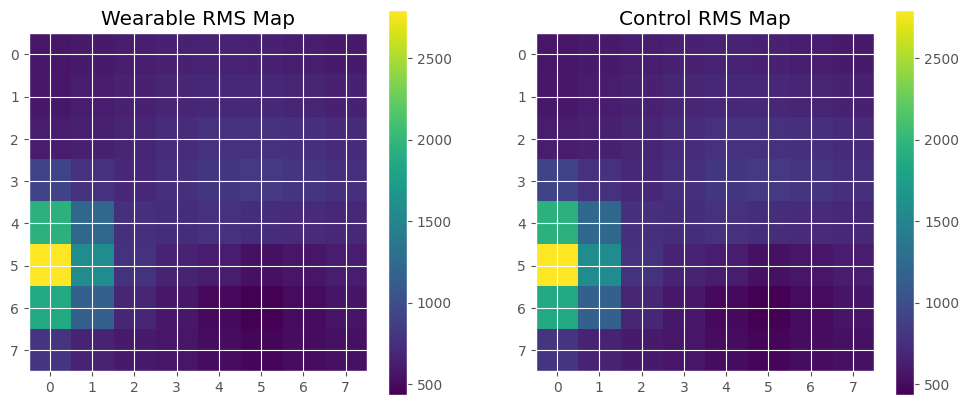

In [19]:
# Compute RMS across full trial
wearable_grid = []
control_grid = []

for ch in range(1, 65):
    w = wearable_interp[f"Channel_{ch}"].values
    c = control_interp[f"Channel_{ch}"].values
    wearable_grid.append(np.sqrt(np.mean(w**2)))
    control_grid.append(np.sqrt(np.mean(c**2)))

wearable_grid = np.array(wearable_grid).reshape(8, 8)
control_grid  = np.array(control_grid).reshape(8, 8)

# Smooth for visualization
wearable_smooth = gaussian_filter(wearable_grid, sigma=1)
control_smooth = gaussian_filter(control_grid, sigma=1)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax[0].imshow(wearable_smooth, cmap="viridis")
im2 = ax[1].imshow(control_smooth, cmap="viridis")

ax[0].set_title("Wearable RMS Map")
ax[1].set_title("Control RMS Map")

plt.colorbar(im1, ax=ax[0])
plt.colorbar(im2, ax=ax[1])
plt.show()


Peak RMS for Specified Channel

Channel 41 Peak RMS Analysis:
  Wearable - Peak RMS: 14795.813464, Mean RMS: 9043.342230
  Control  - Peak RMS: 14795.813464, Mean RMS: 9043.342230
  Peak Difference: 0.000000 (0.00%)
  Mean Difference: 0.000000 (0.00%)


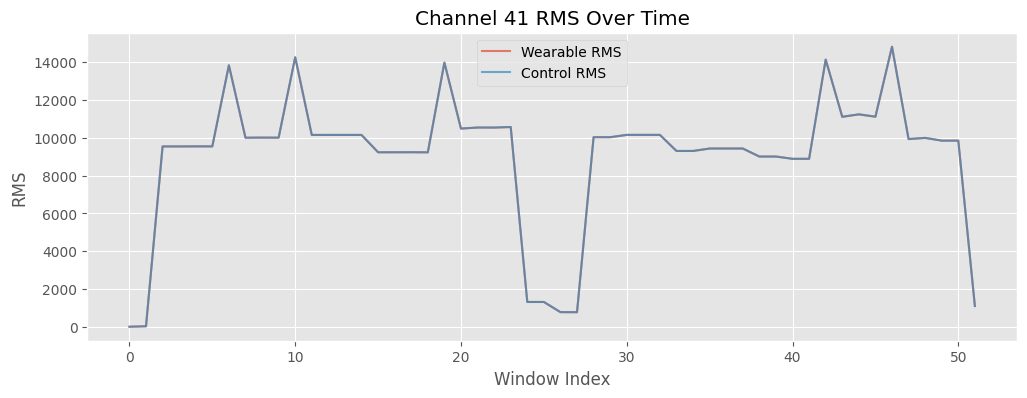

In [20]:
# Specify which channel to analyze
channel_num = 41  # Change this to any channel 1-64

w_signal = wearable_interp[f"Channel_{channel_num}"].values
c_signal = control_interp[f"Channel_{channel_num}"].values

# Calculate peak RMS using sliding windows
# Window size: 1000 samples = 1 second (at 1000 Hz)
window_size = min(1000, len(w_signal) // 10)  # Adapt to signal length

rms_w = [np.sqrt(np.mean(w_signal[i:i+window_size]**2)) 
         for i in range(len(w_signal) - window_size + 1)]
rms_c = [np.sqrt(np.mean(c_signal[i:i+window_size]**2)) 
         for i in range(len(c_signal) - window_size + 1)]

w_peak_rms = max(rms_w)
c_peak_rms = max(rms_c)
w_mean_rms = np.mean(rms_w)
c_mean_rms = np.mean(rms_c)

print(f"Channel {channel_num} Peak RMS Analysis:")
print(f"  Wearable - Peak RMS: {w_peak_rms:.6f}, Mean RMS: {w_mean_rms:.6f}")
print(f"  Control  - Peak RMS: {c_peak_rms:.6f}, Mean RMS: {c_mean_rms:.6f}")
print(f"  Peak Difference: {abs(w_peak_rms - c_peak_rms):.6f} ({100 * abs(w_peak_rms - c_peak_rms) / max(c_peak_rms, 1e-9):.2f}%)")
print(f"  Mean Difference: {abs(w_mean_rms - c_mean_rms):.6f} ({100 * abs(w_mean_rms - c_mean_rms) / max(c_mean_rms, 1e-9):.2f}%)")

# Plot RMS over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rms_w, label="Wearable RMS", alpha=0.7)
ax.plot(rms_c, label="Control RMS", alpha=0.7)
ax.set_xlabel("Window Index")
ax.set_ylabel("RMS")
ax.set_title(f"Channel {channel_num} RMS Over Time")
ax.legend()
plt.show()
